In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

Q1. Use rejection sampling to draw 1000 samples from this distribution.  Show that the samples you've drawn are correctly distributed according to this probability density function

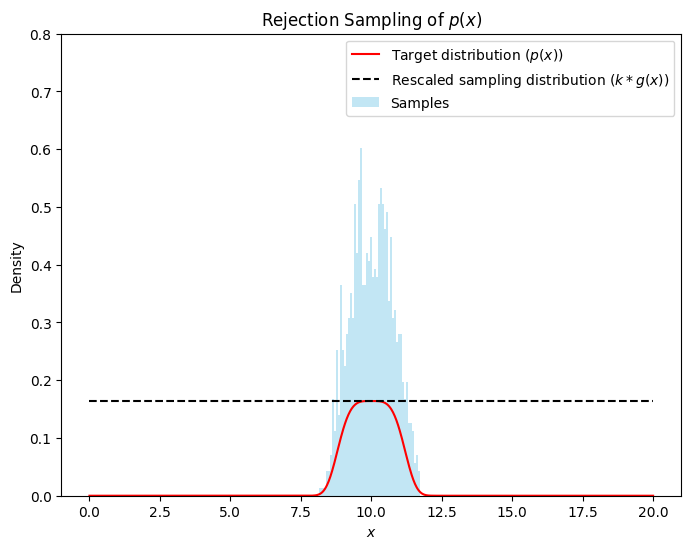

In [36]:
# Target distribution (PDF)
def p(x):
    return 0.164 * np.exp(-((x - 10) ** 4) /2.78)

# Proposal distribution (uniform)
a, b = 0, 20
def g(x):
    return np.where((x >= a) & (x <= b), 1 / (b - a), 0)

# Find the scaling constant k
x_values = np.linspace(a, b, 1000)
k = np.max(p(x_values) / g(x_values))

# Rejection sampling function
def rejection_sampling(iter=1000):
    samples = []
    
    while len(samples) < iter:
        z = np.random.uniform(a, b)  # Sample from uniform distribution
        u = np.random.uniform(0, k * g(z))  
        
        if u <= p(z):  
            samples.append(z)
    
    return np.array(samples)


samples = rejection_sampling(iter=1000)


x = np.linspace(0, 20, 1000)
plt.figure(figsize=(8, 6))
plt.plot(x, p(x), label='Target distribution ($p(x)$)', color='red')
plt.plot(x, k * g(x), label='Rescaled sampling distribution ($k * g(x)$)', color='black', linestyle='dashed')
plt.hist(samples, bins=50, density=True, alpha=0.5, label='Samples', color='skyblue')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('Density')
plt.title('Rejection Sampling of $p(x)$')
plt.ylim(0, 0.8)
plt.show()

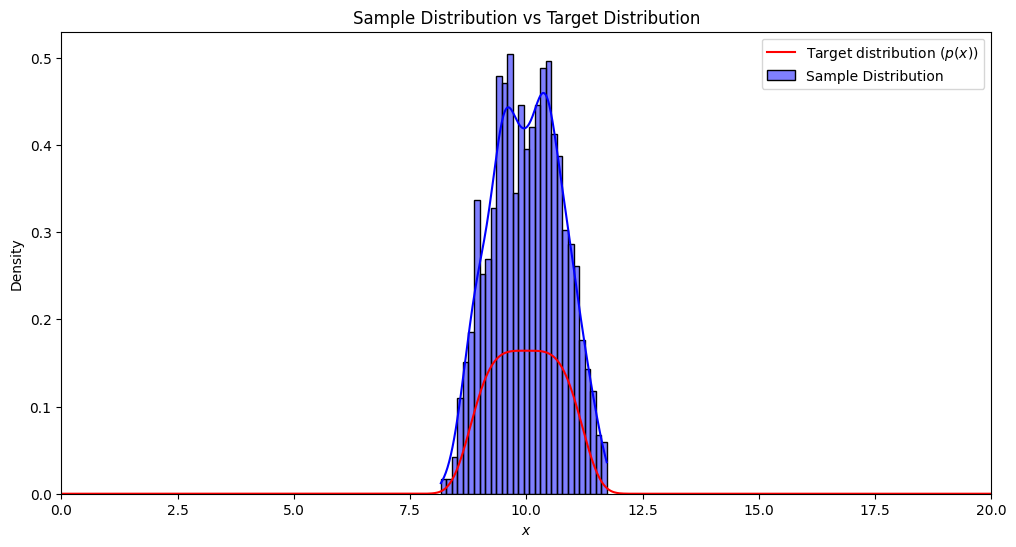

1000 samples drawn from the target distribution


In [37]:

# Plotting the distribution of the samples
plt.figure(figsize=(12, 6))
sns.histplot(samples, bins=30, kde=True, stat='density', color='blue', label='Sample Distribution')
plt.plot(x, p(x), label='Target distribution ($p(x)$)', color='red')
plt.xlim(0, 20)
plt.xlabel('$x$')
plt.ylabel('Density')
plt.title('Sample Distribution vs Target Distribution')
plt.legend()
plt.show()

print(f"{len(samples)} samples drawn from the target distribution")

Q2. Use importance sampling to estimate the expectation value of 
x
, and compare it to the mean of the samples you drew in part 1.

Estimated E[x] using importance sampling: 9.95889956319778
Mean of samples drawn from g(x): 9.692446459781165


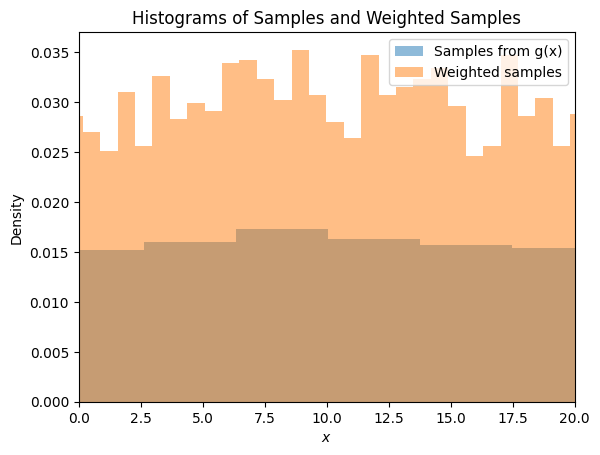

In [38]:
# Define the target PDF p(x)
def p(x):
    return 0.164 * np.exp(-((x - 10)**4) / (2 * 8**2))

# Define the sampling distribution g(x)
mu = 10  # Example value for mu
sigma = 8  # Example value for sigma
μ_g = mu
σ_g = 3 * sigma
X_g = norm(loc=μ_g, scale=σ_g)

# Number of samples
S = 10000

# Draw samples from g(x)
x_gs = X_g.rvs(S)

# Compute weights
ws = p(x_gs) / X_g.pdf(x_gs)

# Estimate E[x]
E_x = np.sum(x_gs * ws) / np.sum(ws)
print("Estimated E[x] using importance sampling:", E_x)

# Compare with the mean of the samples
mean_samples = np.mean(x_gs)
print("Mean of samples drawn from g(x):", mean_samples)

# Plot the histograms
plt.hist(x_gs, bins=50, density=True, alpha=0.5, label='Samples from g(x)')
plt.hist(x_gs[ws > 0], bins=50, density=True, alpha=0.5, label='Weighted samples')
plt.title('Histograms of Samples and Weighted Samples')
plt.xlabel('$x$')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 20)
plt.show()


Q3. Calculate the expectation value of 
x
2
.

Estimated E[x^2] using importance sampling: 104.35697271916055
Mean of squared samples drawn from g(x): 667.0239564981151


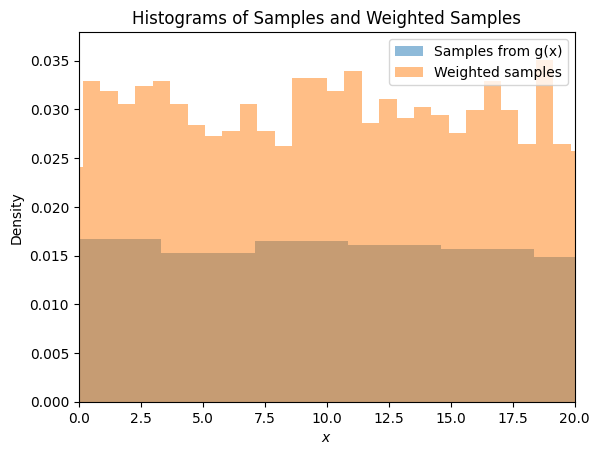

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the target PDF p(x)
def p(x):
    return 0.164 * np.exp(-((x - 10)**4) / (2 * 8**2))

# Define the sampling distribution g(x)
mu = 10  # Example value for mu
sigma = 8  # Example value for sigma
μ_g = mu
σ_g = 3 * sigma
X_g = norm(loc=μ_g, scale=σ_g)

# Number of samples
S = 10000

# Draw samples from g(x)
x_gs = X_g.rvs(S)

# Compute weights
ws = p(x_gs) / X_g.pdf(x_gs)

# Estimate E[x^2]
E_x2 = np.sum(x_gs**2 * ws) / np.sum(ws)
print("Estimated E[x^2] using importance sampling:", E_x2)

# Compare with the mean of the squared samples
mean_squared_samples = np.mean(x_gs**2)
print("Mean of squared samples drawn from g(x):", mean_squared_samples)

# Optional: Plot histograms
plt.hist(x_gs, bins=50, density=True, alpha=0.5, label='Samples from g(x)')
plt.hist(x_gs[ws > 0], bins=50, density=True, alpha=0.5, label='Weighted samples')
plt.title('Histograms of Samples and Weighted Samples')
plt.xlabel('$x$')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 20)
plt.show()


Q5. Revisit the importance sampling example from the Intro to Sampling notebook from class. There we demonstrated the use of importance sampling to estimate the expectation value of some function of our random variable. We could also use the weights we computed to probabilistically choose samples from the sampling distribution to keep, in an effort to "reweigh" the sampling distribution to correspond to the target distribution. Try to implement this, and see if your resampled distribution's histogram matches the target distribution's probability density